# Métricas do sistemas
---

### Bibliotecas

---

Caso não consiga instalar execute `pip install -r requirements.txt` no terminal

In [1]:
!uv pip install -r ../requirements.txt

Using Python 3.10.11 environment at: C:\Users\Victo\Desktop\Ufal\obi-benchmarking\.venv
Checked 10 packages in 1.23s


In [132]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json

In [110]:
path_database = Path("../database")
questions_path = []
        
for folder in list(path_database.iterdir()):
    if folder.is_dir():
        questions_path.append(folder)
        
problems = []
questions_name = []
for question_path in questions_path:
    
    path_imgs = question_path / "imgs"
    path_test_cases = question_path / "test_cases"
    
    if path_test_cases.exists() and path_imgs.exists():
        questions_name.append(question_path.name)
        problems.append(json.loads(Path(question_path / "problem.json").read_text(encoding="utf-8")))
        
print(f"Quantidade de problemas com imagens: {len(problems)}")

Quantidade de problemas com imagens: 181


In [111]:
for problem in problems:
    print(problem["title"])

Caça ao Tesouro
Gomoku
Notas da Prova
Jogo da Vida
Muro
O Chefe
Proteja sua senha
Chinelos
Jogo dos copos
Tiro ao Alvo
Robô
Transportes
Jogo de Dominós
Arco e flecha
Móbile
Campo de Minhocas
Entrega de Caixas
Cinema
Montanha
Torre
Mesa redonda
Pizzaria
Redes de Descanso
Mancha
Escher
Nova avenida
Game Show
Manchas de pele
Castelos da Nlogônia
Capitais
Quadrado Mágico
Piloto Automático
Falta uma
Palavras Cruzadas
Piso da escola
Ônibus
Chocolate em barra
Campo Minado
Fila
Jogo dos Pinos
Diagonal
Sr. Toupeira
Sr. Sapo
Duende Perdido
Bingo!
Ponto do meio
Game-10
TV da Vovó
Dança Indígena
Chuva
Dança de Formatura
Cubo Preto
Competição de chocolate
Reduzindo detalhes em um mapa
Dominó
Caminho das Pontes
Macacos me mordam!
Rodovia
VAR
Computador
Pulo do Gato
Semente
Álbum de fotos
Toca do Saci
Caminhos do reino
Cartas
Flíper
Avião
Medalhas
Elevador
Cubra os Furos
Carro elétrico
Dario e Xerxes
Quadrado Aritmético
O Tabuleiro Esburacado
Retas
Viagem
Soma
Estoque
Frete
Caçadores de Mitos
Linhas 

In [112]:
df_problems = pd.DataFrame(problems)
counts_difficulty = {}

for d in df_problems["difficulty"].unique():
    cases = df_problems[df_problems["difficulty"] == d]
    counts_difficulty[d] = len(cases)
    
print(counts_difficulty)

{'Médio': 81, 'Fácil': 67, 'Difícil': 33}


[67, 81, 33]
['Fácil', 'Médio', 'Difícil']


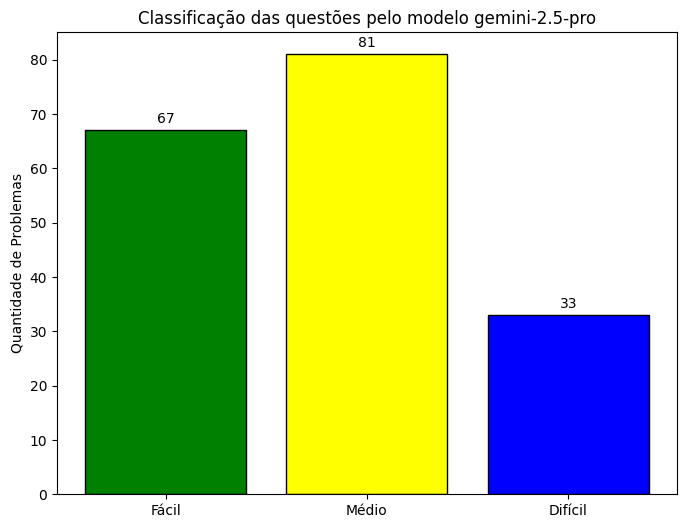

In [113]:
X = ["Fácil", "Médio", "Difícil"]
y = [counts_difficulty[x] for x in X]

print(y)
print(X)
plt.figure(figsize=(8, 6))

bar_plot = plt.bar(X, y, color=['green', 'yellow', 'blue'], edgecolor='black')

plt.bar_label(bar_plot, padding=3)

plt.title("Classificação das questões pelo modelo gemini-2.5-pro")
plt.ylabel('Quantidade de Problemas')
plt.show()

### PROMPT: QUESTÕES COM IMAGENS NA BASE64 vs QUESTÕES SEM IMAGENS
---

In [114]:
files_path = Path("../output/cbsoft_sbes_2026/results/")
dataset = {}

count_total_tokens = {}

for path in files_path.rglob("*"):
    if not path.is_file():
        continue
    
    df = pd.read_csv(path)
    
    name = path.name.replace(".csv", "")
    count_total_tokens[name] = 0
    
    dataset[name] = df
    
    for value in df["total_tokens"]:
        count_total_tokens[name] += value
        
for key, value in count_total_tokens.items():
    print(f"file: {key} | total de tokens: {value}")

file: results_x_ai_grok_4_20_python_zero_img | total de tokens: 324413
file: results_anthropic_claude_sonnet_4_6_python_zero_img | total de tokens: 370949
file: results_google_gemini_3_1_pro_preview_python_zero_noimg | total de tokens: 928250
file: results_gpt_5_4_python_zero_noimg | total de tokens: 203283
file: results_mistralai_mistral_small_2603_python_zero_img | total de tokens: 263588
file: results_x_ai_grok_4_20_python_zero_noimg | total de tokens: 354468
file: results_mistralai_mistral_small_2603_python_zero_noimg | total de tokens: 219431
file: results_google_gemini_3_1_pro_preview_python_zero_img | total de tokens: 1183470
file: results_anthropic_claude_sonnet_4_6_python_zero_noimg | total de tokens: 307314
file: results_gpt_5_4_python_zero_img | total de tokens: 240511


In [115]:
def success_rate_in_case_tests(files_path: Path = Path('../output/cbsoft_sbes_2026/results/'), type: str = '_img'):
    
    dataset = {}
    for path in files_path.rglob('*'):
        if not path.is_file():
            continue

        parts = str(path).split("results_")
        if len(parts) < 2:
            continue
                    
        if not (type in path.name):
            continue
            
        if path.stat().st_size == 0:
            print(f"⚠️ Arquivo vazio ignorado: {path.name}")
            continue

        try:
            df = pd.read_csv(path)
            model_name = path.name.replace(".csv", "")
            
            print(model_name)
            if model_name not in dataset:
                dataset[model_name] = df
            else:
                dataset[model_name] = pd.concat([dataset[model_name], df], ignore_index=True)
            
        except ValueError as e:
            print(f"Erro de ValueError (JSON malformado) no arquivo: {path.name}")
            print(f"   -> Detalhe: {e}")
        except Exception as e:
            print(f"Erro inesperado ao ler {path.name}: {e}")

    count = 0
    for data in dataset["results_gpt_5_4_python_zero" + type]["total_test_cases"]:
        count += data
    
    print("Total de caso testes: ", count)
    rows = []
    for model, data in dataset.items():
        rows.append({
            "Modelo": model,
            "AC":  data["AC"].sum()  / count,
            "WA":  data["WA"].sum()  / count,
            "RE":  data["RE"].sum()  / count,
            "TLE": data["TLE"].sum() / count,
            "CE":  data["CE"].sum()  / count,
        })

    df_results = pd.DataFrame(rows)

    display(
        df_results.style
        .format({
            "AC":  "{:.2%}",
            "WA":  "{:.2%}",
            "RE":  "{:.2%}",
            "TLE": "{:.2%}",
            "CE":  "{:.2%}",
        })
    )

In [116]:
#colocar com _type
success_rate_in_case_tests(type='_img')

results_x_ai_grok_4_20_python_zero_img
results_anthropic_claude_sonnet_4_6_python_zero_img
results_mistralai_mistral_small_2603_python_zero_img
results_google_gemini_3_1_pro_preview_python_zero_img
results_gpt_5_4_python_zero_img
Total de caso testes:  6708


,Modelo,AC,WA,RE,TLE,CE
0,results_x_ai_grok_4_20_python_zero_img,65.34%,23.33%,7.77%,3.56%,0.00%
1,results_anthropic_claude_sonnet_4_6_python_zero_img,81.05%,5.41%,11.17%,2.37%,0.00%
2,results_mistralai_mistral_small_2603_python_zero_img,55.87%,33.62%,6.75%,3.76%,0.00%
3,results_google_gemini_3_1_pro_preview_python_zero_img,96.69%,2.89%,0.42%,0.00%,0.00%
4,results_gpt_5_4_python_zero_img,79.23%,17.90%,2.25%,0.61%,0.00%


In [117]:
success_rate_in_case_tests(type='_noimg')

results_google_gemini_3_1_pro_preview_python_zero_noimg
results_gpt_5_4_python_zero_noimg
results_x_ai_grok_4_20_python_zero_noimg
results_mistralai_mistral_small_2603_python_zero_noimg
results_anthropic_claude_sonnet_4_6_python_zero_noimg
Total de caso testes:  6708


,Modelo,AC,WA,RE,TLE,CE
0,results_google_gemini_3_1_pro_preview_python_zero_noimg,96.66%,2.92%,0.42%,0.00%,0.00%
1,results_gpt_5_4_python_zero_noimg,78.00%,19.16%,2.52%,0.33%,0.00%
2,results_x_ai_grok_4_20_python_zero_noimg,62.25%,23.76%,11.09%,2.89%,0.00%
3,results_mistralai_mistral_small_2603_python_zero_noimg,61.08%,30.08%,5.50%,3.34%,0.00%
4,results_anthropic_claude_sonnet_4_6_python_zero_noimg,81.86%,6.90%,8.35%,2.89%,0.00%


In [118]:
def average(data):
    n = len(data)
    count = 0
    
    for value in data:
        count += value
        
    return float(count/n)

In [119]:
def per_ac_questions(data):
    n = len(data)
    count = 0
    for value in data["judge_predict"]:
        if value == "AC":
            count += 1
            
    return float(count/n)

In [120]:
def table_with_info(type: str = "_img"):
    files_path = Path("../output/cbsoft_sbes_2026/results/")

    dataset = {}

    for path in list(files_path.rglob('*')):        
        model = str(path).split("results_")[1]
        if not type in model:
            continue
        
        model = model.split("_python_zero")[0]
        
        dataset[model] = pd.read_csv(path)
    
    metrics = {}

    for key, data in dataset.items():
        
        row = {}
        
        hard_questions = data[data["difficulty"] == "Difícil"]
        row['hard_ac'] = per_ac_questions(hard_questions)
        
        medium_questions = data[data["difficulty"] == "Médio"]
        row['medium_ac'] = per_ac_questions(medium_questions)
        
        easy_questions = data[data["difficulty"] == "Fácil"]
        row['easy_ac'] = per_ac_questions(easy_questions)
        
        row['avg_tokens'] = average(data["total_tokens"])
        row['avg_cost'] = average(data["cost_prompt"])
        row['avg_create_code'] = average(data["llm_code_creation_time"])
        
        metrics[key] = row
    
    rows = []
    names_model = {
        "anthropic_claude_sonnet_4_6": "Claude Sonnet 4.6",
        "gpt_5_4": "GPT 5.4",
        "x_ai_grok_4_20": "Grok 4.20",
        "google_gemini_3_1_pro_preview": "Gemini 3.1 Pro",
        "mistralai_mistral_small_2603": "Mistral Small 4"
    }

    for key, data in metrics.items():
        rows.append({
            "Modelo":               names_model[key],
            "Fácil AC (%)":         data["easy_ac"] * 100,
            "Média AC (%)":         data["medium_ac"] * 100,
            "Difícil AC (%)":       data["hard_ac"] * 100,
            "Tokens (Média)":       data["avg_tokens"],
            "Custo Médio (US$)":    data["avg_cost"],
            "Tempo Médio (s)":      data["avg_create_code"], 
        })

    df = pd.DataFrame(rows).sort_values("Modelo").reset_index(drop=True)

    display(
        df.style
        .format({
            "Fácil AC (%)":       "{:.2f}",
            "Média AC (%)":       "{:.2f}",
            "Difícil AC (%)":     "{:.2f}",
            "Tokens (Média)":     "{:.0f}",
            "Custo Médio (US$)":  "{:.4f}",
            "Tempo Médio (s)":    "{:.0f}",
        })
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([dict(selector='th', props=[('text-align', 'center')])])
        .hide(axis="index")
    )

In [121]:
table_with_info("_img")

Modelo,Fácil AC (%),Média AC (%),Difícil AC (%),Tokens (Média),Custo Médio (US$),Tempo Médio (s)
Claude Sonnet 4.6,83.58,71.60,33.33,2049,0.0148,12
GPT 5.4,82.09,69.14,36.36,1329,0.0065,4
Gemini 3.1 Pro,97.01,88.89,84.85,6539,0.0567,39
Grok 4.20,73.13,53.09,15.15,1792,0.0061,7
Mistral Small 4,61.19,41.98,12.12,1456,0.0018,3


In [122]:
table_with_info("_noimg")

Modelo,Fácil AC (%),Média AC (%),Difícil AC (%),Tokens (Média),Custo Médio (US$),Tempo Médio (s)
Claude Sonnet 4.6,77.61,75.31,36.36,1698,0.0121,9
GPT 5.4,80.60,69.14,30.30,1123,0.0059,4
Gemini 3.1 Pro,97.01,88.89,84.85,5128,0.0520,38
Grok 4.20,61.19,54.32,18.18,1958,0.0078,9
Mistral Small 4,58.21,49.38,9.09,1212,0.0016,3


# Acertos por tópicos: grafos e programação dinâmica
---

In [130]:
total = 0

for key, data in dataset.items():
    total_cost = 0

    for count_test in data["cost_prompt"]:
        total_cost += count_test
    
    total += total_cost
    
    print(f"Total do custo [{key}]: U$ {total_cost:.2f}")
    
print(f"Valor gasto atualmente: U$ {total:.2f}")

Total do custo [results_x_ai_grok_4_20_python_zero_img]: U$ 1.10
Total do custo [results_anthropic_claude_sonnet_4_6_python_zero_img]: U$ 2.67
Total do custo [results_google_gemini_3_1_pro_preview_python_zero_noimg]: U$ 9.42
Total do custo [results_gpt_5_4_python_zero_noimg]: U$ 1.07
Total do custo [results_mistralai_mistral_small_2603_python_zero_img]: U$ 0.32
Total do custo [results_x_ai_grok_4_20_python_zero_noimg]: U$ 1.41
Total do custo [results_mistralai_mistral_small_2603_python_zero_noimg]: U$ 0.29
Total do custo [results_google_gemini_3_1_pro_preview_python_zero_img]: U$ 10.26
Total do custo [results_anthropic_claude_sonnet_4_6_python_zero_noimg]: U$ 2.19
Total do custo [results_gpt_5_4_python_zero_img]: U$ 1.17
Valor gasto atualmente: U$ 29.91


In [123]:
topics_unique = set()

for problem in problems:
    for topic in problem["topics"]:
        topics_unique.add(topic)
        
print(topics_unique)

{'geometria', 'caminho mínimo', 'árvore geradora mínima', 'queries', 'grafos', 'backtracking', 'contagem de inversões', 'mathematics', 'condicional', 'loops', 'dijkstra', 'bitwise', 'strings', 'estruturas condicionais', 'condicionais', 'força bruta', 'Busca em Profundidade (DFS)', 'diâmetro', 'array circular', 'brute force', 'Árvore Geradora Mínima', 'árvore de segmentos', 'LCA', 'mediana', 'Backtracking', 'Ad-hoc', 'estrutura de dados', 'arrays', 'algoritmo de dijkstra', 'árvores', 'BFS/DFS', 'árvore de fenwick', 'Matemática', 'dois ponteiros', 'Grafos', 'Busca em Largura', 'algoritmos gulosos', 'bfs', 'convex hull trick', 'autômato celular', 'matemática', 'recursão', 'pré-processamento', 'matrizes', 'busca em grade', 'two pointers', 'otimização', 'combinatória', 'guloso', 'arredondamento', 'ordenação', 'busca em largura', 'geometria espacial', 'permutações', 'inversões', 'componentes conexos', 'estruturas de dados', 'busca binária', 'busca', 'array', 'Força Bruta', 'teoria dos número

In [124]:
topics = []

for problem in problems:
    if problem.get("topics") is not None:
        topics.extend(problem["topics"])

print(set(topics))

topics_grafos = [
    'grafos', 
    'ciclos em grafos', 
    'busca em largura', 
    'busca em profundidade',
    'caminho mínimo', 
    'árvore geradora mínima', 
    'dijkstra', 
    'Busca em Profundidade (DFS)', 
    'diâmetro', 
    'Árvore Geradora Mínima', 
    'LCA', 
    'algoritmo de dijkstra', 
    'árvores', 
    'BFS/DFS', 
    'Grafos', 
    'Busca em Largura', 
    'bfs', 
    'componentes conexos', 
    'Árvores', 
    'componentes fortemente conexos', 
    'busca em largura (bfs)', 
    'dfs/bfs', 
    'componentes conexas', 
    'busca em grafos', 
    'flood fill', 
    'dfs'
]

topics_pd = [
    'programação dinâmica',
    'Programação Dinâmica', 
    'kadane', 
    'convex hull trick'
]

questions_by_topics = {"g": set(), "pd": set()}

for name, problem in zip(questions_name, problems):
    topicos = [t.lower() for t in problem.get('topics', [])]
    if any(t in topics_grafos for t in topicos):
        questions_by_topics["g"].add(name)
    elif any(t in topics_pd for t in topicos):
        questions_by_topics["pd"].add(name)

print(questions_by_topics)
print(f"grafos: {len(questions_by_topics['g'])}, programação dinâmica: {len(questions_by_topics['pd'])}")

{'geometria', 'caminho mínimo', 'árvore geradora mínima', 'queries', 'grafos', 'backtracking', 'contagem de inversões', 'mathematics', 'condicional', 'loops', 'dijkstra', 'bitwise', 'strings', 'estruturas condicionais', 'condicionais', 'força bruta', 'Busca em Profundidade (DFS)', 'diâmetro', 'array circular', 'brute force', 'Árvore Geradora Mínima', 'árvore de segmentos', 'LCA', 'mediana', 'Backtracking', 'Ad-hoc', 'estrutura de dados', 'arrays', 'algoritmo de dijkstra', 'árvores', 'BFS/DFS', 'árvore de fenwick', 'Matemática', 'dois ponteiros', 'Grafos', 'Busca em Largura', 'algoritmos gulosos', 'bfs', 'convex hull trick', 'autômato celular', 'matemática', 'recursão', 'pré-processamento', 'matrizes', 'busca em grade', 'two pointers', 'otimização', 'combinatória', 'guloso', 'arredondamento', 'ordenação', 'busca em largura', 'geometria espacial', 'permutações', 'inversões', 'componentes conexos', 'estruturas de dados', 'busca binária', 'busca', 'array', 'Força Bruta', 'teoria dos número

In [138]:
#Pegando só as questões de grafos e pd por nome
total_test_cases = {'g': 0, 'pd': 0}
for _, row in dataset["results_x_ai_grok_4_20_python_zero_img"].iterrows():
    if row["question_name"] in list(questions_by_topics['g']):
        total_test_cases['g'] += row['total_test_cases']
    elif row["question_name"] in questions_by_topics['pd']:
        total_test_cases['pd'] += row['total_test_cases']

print(f"Total de casos de teste dessa lista: {total_test_cases['g'] + total_test_cases['pd']}")

Total de casos de teste dessa lista: 2491


In [ ]:
data_by_dataset = {}
for key, data in dataset.items():
    data_by_dataset[key] = {'g': 0, 'pd': 0}
    
    df = pd.DataFrame(data)
    df = df[df["judge_predict"] == "AC"]
    df.head()
    
    for _, row in df.iterrows():
        if row["question_name"] in list(questions_by_topics['g']):
            data_by_dataset[key]['g'] += row['AC']
        elif row["question_name"] in questions_by_topics['pd']:
            data_by_dataset[key]['pd'] += row['AC']

for key, value in data_by_dataset.items():
    print(f"{key}: {value}")

results_x_ai_grok_4_20_python_zero_img: {'g': 856, 'pd': 90}
results_anthropic_claude_sonnet_4_6_python_zero_img: {'g': 1073, 'pd': 266}
results_google_gemini_3_1_pro_preview_python_zero_noimg: {'g': 1692, 'pd': 486}
results_gpt_5_4_python_zero_noimg: {'g': 1092, 'pd': 174}
results_mistralai_mistral_small_2603_python_zero_img: {'g': 506, 'pd': 80}
results_x_ai_grok_4_20_python_zero_noimg: {'g': 846, 'pd': 90}
results_mistralai_mistral_small_2603_python_zero_noimg: {'g': 621, 'pd': 108}
results_google_gemini_3_1_pro_preview_python_zero_img: {'g': 1692, 'pd': 486}
results_anthropic_claude_sonnet_4_6_python_zero_noimg: {'g': 1174, 'pd': 158}
results_gpt_5_4_python_zero_img: {'g': 1148, 'pd': 194}


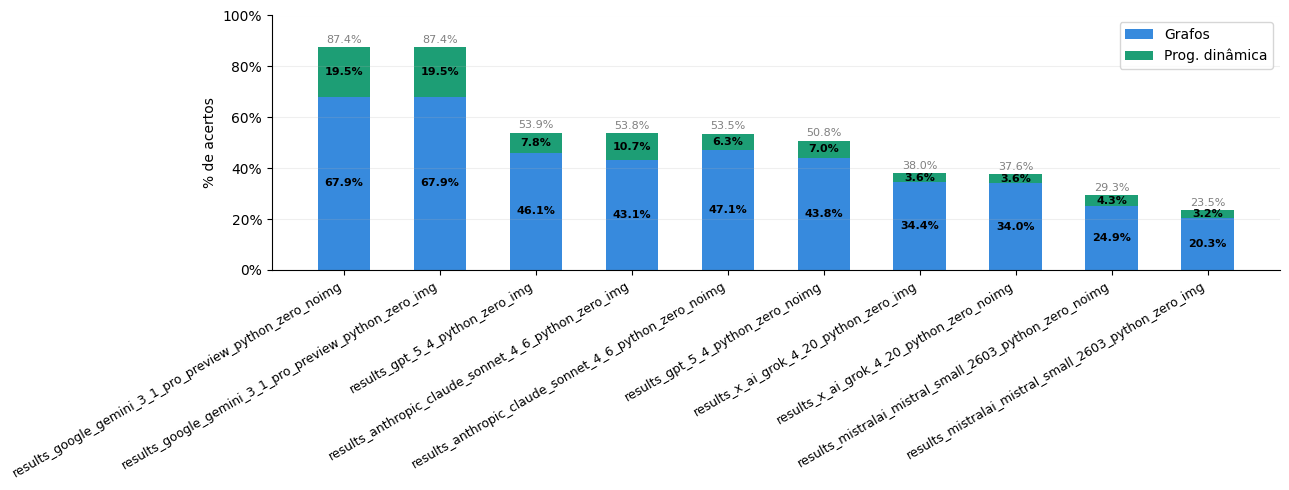

In [139]:
len_g = total_test_cases['g']
len_pd = total_test_cases['pd']
modelos = list(data_by_dataset.keys())
modelos_sorted = sorted(data_by_dataset.keys(), key=lambda k: data_by_dataset[k]['g'] + data_by_dataset[k]['pd'], reverse=True)
modelos = modelos_sorted
raw_g  = [data_by_dataset[k]['g']  for k in modelos]
raw_pd = [data_by_dataset[k]['pd'] for k in modelos]
g_pct  = [v / (len_g + len_pd) * 100 for v in raw_g]
pd_pct = [v / (len_g + len_pd) * 100 for v in raw_pd]

x = np.arange(len(modelos))
w = 0.55

fig, ax = plt.subplots(figsize=(13, 5))
bars_g  = ax.bar(x, g_pct,  w, label='Grafos',         color='#378ADD')
bars_pd = ax.bar(x, pd_pct, w, label='Prog. dinâmica', color='#1D9E75', bottom=g_pct)

for i in range(len(modelos)):
    # % dentro da barra de grafos
    if g_pct[i] > 3:
        ax.text(x[i], g_pct[i] / 2, f'{g_pct[i]:.1f}%',
                ha='center', va='center', fontsize=8, color='black', fontweight='bold')

    # % dentro da barra de prog. dinâmica
    if pd_pct[i] > 3:
        ax.text(x[i], g_pct[i] + pd_pct[i] / 2, f'{pd_pct[i]:.1f}%',
                ha='center', va='center', fontsize=8, color='black', fontweight='bold')

    # % total acima da barra
    total = g_pct[i] + pd_pct[i]
    ax.text(x[i], total + 1, f'{total:.1f}%',
            ha='center', va='bottom', fontsize=8, color='gray')

ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('% de acertos')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.legend()
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()